# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [2]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Modules
Python_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode
Data_folder: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Data
Training data shape (DK1): (78900, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78900, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Choose validation setup


**Setup 1**

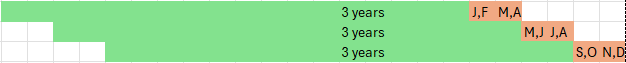

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [3]:
setup = 2

In [ ]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Define ARIMA helpers

In [ ]:
import itertools
import os
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from Modules.Validation2 import _build_validation_folds, smape

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def _prepare_target_series(data, target_col):
    series = (
        data[["Time", target_col]]
        .copy()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .set_index("Time")[target_col]
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    return series.asfreq("h")


def _fit_arima(train_series, order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        fitted_model = ARIMA(
            train_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    return fitted_model


def _build_weekly_and_daily_metrics(actual, predicted, fold_no, week_no):
    evaluation = pd.DataFrame(
        {
            "Time": actual.index,
            "Actual": actual.values,
            "Prediction": predicted.reindex(actual.index).values,
        }
    )
    evaluation["Date"] = evaluation["Time"].dt.floor("D")

    rmse = float(np.sqrt(np.mean((evaluation["Actual"] - evaluation["Prediction"]) ** 2)))
    mae = float(np.mean(np.abs(evaluation["Actual"] - evaluation["Prediction"])))
    smape_value = float(smape(evaluation["Actual"].values, evaluation["Prediction"].values))

    weekly_row = {
        "fold": fold_no,
        "week": week_no,
        "week_start": evaluation["Time"].min(),
        "week_end": evaluation["Time"].max(),
        "weekly_rmse": rmse,
        "weekly_mae": mae,
        "weekly_smape": smape_value,
    }

    daily_rows = []
    for date, day_group in evaluation.groupby("Date"):
        daily_rows.append(
            {
                "Date": date,
                "daily_rmse": float(
                    np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))
                ),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                "fold": fold_no,
                "week": week_no,
            }
        )

    return weekly_row, pd.DataFrame(daily_rows)


def run_arima_search(
    *,
    price_zone,
    train_data,
    test_data,
    param_grid,
    output_subfolder,
    base_filename,
    train_window,
    val_window,
    val_start,
    predict_period,
    stride,
):
    dataset = pd.concat([train_data, test_data], ignore_index=True)
    dataset = dataset.sort_values("Time").reset_index(drop=True)
    target_col = dataset.columns[0]

    folds = _build_validation_folds(
        data=dataset,
        train_window=train_window,
        val_window=val_window,
        val_start=val_start,
        predict_period=predict_period,
        stride=stride,
    )

    first_fold = folds[0]
    train_mask = (
        (dataset["Time"] >= first_fold["train_start"])
        & (dataset["Time"] <= first_fold["train_end"])
    )
    train_series = _prepare_target_series(dataset.loc[train_mask], target_col)

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    num_combinations = len(all_combinations)

    max_horizon = int(
        (folds[-1]["val_end"] - first_fold["train_end"]).total_seconds() // 3600
    )
    forecast_index = pd.date_range(
        start=first_fold["train_end"] + pd.Timedelta(hours=1),
        periods=max_horizon,
        freq="h",
    )

    print(f"Total number of combinations to test: {num_combinations}")

    results = []
    for comb_number, combination in enumerate(all_combinations, start=1):
        params = dict(zip(param_names, combination))
        order = params["order"]

        print(f"\nCombination {comb_number}/{num_combinations}: {params}")

        try:
            fitted_model = _fit_arima(train_series, order=order)
            forecast = pd.Series(fitted_model.forecast(steps=max_horizon), index=forecast_index)
        except Exception as exc:
            print(f"Combination {comb_number} failed: {exc}")
            continue

        weekly_results = []
        daily_results = []

        for fold in folds:
            fold_mask = (
                (dataset["Time"] >= fold["val_start"])
                & (dataset["Time"] <= fold["val_end"])
            )
            fold_actual = _prepare_target_series(dataset.loc[fold_mask], target_col)
            fold_pred = forecast.loc[fold["val_start"]:fold["val_end"]]

            if len(fold_actual) != len(fold_pred):
                raise ValueError(
                    f"Forecast length mismatch in fold {fold['fold']}: "
                    f"actual={len(fold_actual)}, predicted={len(fold_pred)}"
                )

            fold_week_rmse = []
            fold_week_mae = []
            fold_week_smape = []

            for week_no, start in enumerate(range(0, len(fold_actual), 168), start=1):
                week_actual = fold_actual.iloc[start:start + 168]
                week_pred = fold_pred.iloc[start:start + 168]

                weekly_row, daily_rows = _build_weekly_and_daily_metrics(
                    actual=week_actual,
                    predicted=week_pred,
                    fold_no=fold["fold"],
                    week_no=week_no,
                )
                weekly_results.append(weekly_row)
                daily_results.append(daily_rows)

                fold_week_rmse.append(weekly_row["weekly_rmse"])
                fold_week_mae.append(weekly_row["weekly_mae"])
                fold_week_smape.append(weekly_row["weekly_smape"])

        weekly_results_df = pd.DataFrame(weekly_results)
        daily_results_df = pd.concat(daily_results, ignore_index=True)
        daily_results_df = daily_results_df.sort_values(["fold", "week", "Date"]).reset_index(drop=True)
        daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

        overall_daily_rmse_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
        )
        overall_daily_mae_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
        )
        overall_daily_smape_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
        )

        avg_smape_by_day = {
            f"avg_smape_day_{day}": daily_results_df.loc[
                daily_results_df["day_in_week"] == day,
                "daily_smape",
            ].mean()
            for day in range(1, 8)
        }

        row = {
            **params,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values("avg_smape")

    folder = os.path.join(project_root, "Shallow learners", output_subfolder)
    os.makedirs(folder, exist_ok=True)
    filename = os.path.join(folder, f"{base_filename}.csv")

    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1

    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    return results_df, filename


## Find best parameters

### Hyperparameter search for DK1:

View validation folds for the ARIMA search

In [5]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

folds = _build_validation_folds(
    data=DK1_train,
    train_window=3 * 8760,        # 8760 hours = 1 year
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,         # 168 hours = 1 week
    stride=13 * 168,               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=8760 - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Fold {folds[1]['fold']} train start: {folds[1]['train_start']} - train end: {folds[1]['train_end']}")
print(f"Number of folds: {num_folds}")
print(f"Validation window start: {val_start} - validation window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} val start: {folds[fold]['val_start']} - val end: {folds[fold]['val_end']}")
# print(f"Fold {folds[1]['fold']} val start: {folds[1]['val_start']} - val end: {folds[1]['val_end']}")

Fold 1 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Fold 2 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Number of folds: 4
Validation window start: 2024-01-01 00:00:00 - validation window end: 2024-12-30 23:00:00
Prediction period: 28 days 00:00:00
Fold 1 val start: 2024-01-01 00:00:00 - val end: 2024-01-28 23:00:00
Fold 2 val start: 2024-04-01 00:00:00 - val end: 2024-04-28 23:00:00
Fold 3 val start: 2024-07-01 00:00:00 - val end: 2024-07-28 23:00:00
Fold 4 val start: 2024-09-30 00:00:00 - val end: 2024-10-27 23:00:00


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run Cross-Validation

(Remember to give the right path to save the csv with results!)

In [ ]:
param_grid = {
    "order": [
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1),
        (2, 1, 0),
        (2, 1, 1),
        (3, 1, 1),
    ]
}

results_df, filename = run_arima_search(
    price_zone="DK1",
    train_data=DK1_train,
    test_data=DK1_test,
    param_grid=param_grid,
    output_subfolder="ARIMA-ARIMAX",
    base_filename="DK1_hyperparameter_search_results",
    train_window=3 * 8760,
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,
    stride=13 * 168,
)

print(results_df.head())


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total number of combinations to test: 108

Combination 1/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7293
[LightGBM] [Info] Number of data points in the train set: 26280, number of used features: 36
[LightGBM] [Info] Start training from score 977.247323
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 429.318

Average MAE across all weeks in all folds: 367.611

Average SMAPE across all weeks in all folds: 65.300

Combination 2/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 1.0, 'subsample_freq': 1, 'colsample_bytree': 1.0, '

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
param_grid = {
    "order": [
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1),
        (2, 1, 0),
        (2, 1, 1),
        (3, 1, 1),
    ]
}

print(f"Total number of combinations to test: {len(param_grid['order'])}")


Total number of combinations to test: 108


In [ ]:
results_df, filename = run_arima_search(
    price_zone="DK2",
    train_data=DK2_train,
    test_data=DK2_test,
    param_grid=param_grid,
    output_subfolder="ARIMA-ARIMAX",
    base_filename="DK2_hyperparameter_search_results",
    train_window=3 * 8760,
    val_window=8760,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,
    stride=13 * 168,
)

print(results_df.head())


Total number of combinations to test: 108

Combination 1/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003832 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6770
[LightGBM] [Info] Number of data points in the train set: 26280, number of used features: 34
[LightGBM] [Info] Start training from score 940.819901
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 473.870

Average MAE across all weeks in all folds: 413.631

Average SMAPE across all weeks in all folds: 69.430

Combination 2/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 1.0, 'subsample_freq': 1, 'colsample_bytree': 1.0, '

## Train and test final model

Make train and test periods

In [6]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2016-01-01 12:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train and test the final ARIMA model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6899
[LightGBM] [Info] Number of data points in the train set: 78900, number of used features: 34
[LightGBM] [Info] Start training from score 517.786752
Model trained. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 353.373

Average MAE across all weeks in all folds: 275.328

Average SMAPE across all weeks in all folds: 55.534


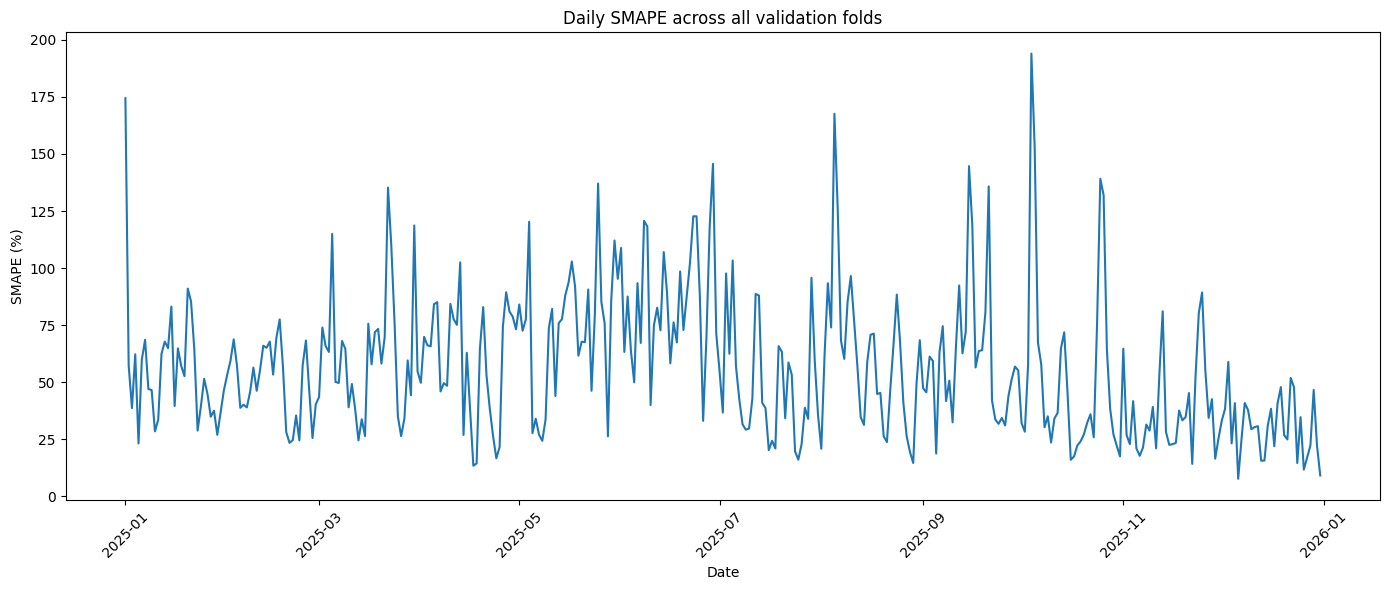


Results saved to: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Shallow learners\LightGBM\DK2_final_LightGBM_results.csv


In [ ]:
import os
import pandas as pd

price_zone = "DK2"
final_order = (1, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

train_series = _prepare_target_series(train_data, train_data.columns[0])
test_series = _prepare_target_series(test_data, test_data.columns[0])

fitted_model = _fit_arima(train_series, final_order)
forecast = pd.Series(
    fitted_model.forecast(steps=len(test_series)),
    index=test_series.index,
)

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners", "ARIMA-ARIMAX")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMA_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")


Shap analysis